# PCA and K-Means
### Objective
This notebook applies unsupervised learning (PCA + K-Means) to identify 
distinct LNG market regimes in the Singapore energy dataset without using 
any labels. The discovered regimes are used to engineer a `regime_cluster` 
feature for supervised modelling in Steps 3–6.

In [1]:
import sys
!{sys.executable} -m pip install scikit-learn matplotlib seaborn numpy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 11.9 MB/s  0:00:00 eta 0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 11.1 MB/s  0:00:001.0 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [seaborn]━━━━━━━━━━ 5/7 [matplotlib]


In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('data/clean/04_features.csv', parse_dates=['date'], index_col='date')

features = ['jkm_price', 'ttf_price', 'henry_price', 'USEP',
            'lng_import_tonnes', 'png_import_tonnes', 'lng_share']

df_pca = df[features].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)

pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

# Print individual (not cumulative) variance for clarity
print("Individual variance explained:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.1%}")
print(f"\nCumulative (PC1+PC2): {pca.explained_variance_ratio_.sum():.1%}")

Individual variance explained:
  PC1: 47.2%
  PC2: 38.1%

Cumulative (PC1+PC2): 85.3%


## PCA — Dimensionality Reduction

**Variance explained:**
- PC1: 47.2% — global gas price level axis (JKM, TTF, USEP co-movement)
- PC2: 38.1% — supply structure axis (LNG share, Henry Hub divergence)
- **Combined: 85.3% of total dataset variance captured in 2D**

This is a strong result — only 14.7% of information is lost in the 
2D projection, meaning the cluster visualisation in PC1-PC2 space is 
a highly faithful representation of the full 7-dimensional dataset.

The high PC1 variance (47.2%) confirms what the correlation heatmap 
showed: global gas price signals (JKM, TTF, USEP) move together so 
strongly that they collectively form one dominant dimension of variation. 
PC1 essentially IS the "global energy price level" at any given month.

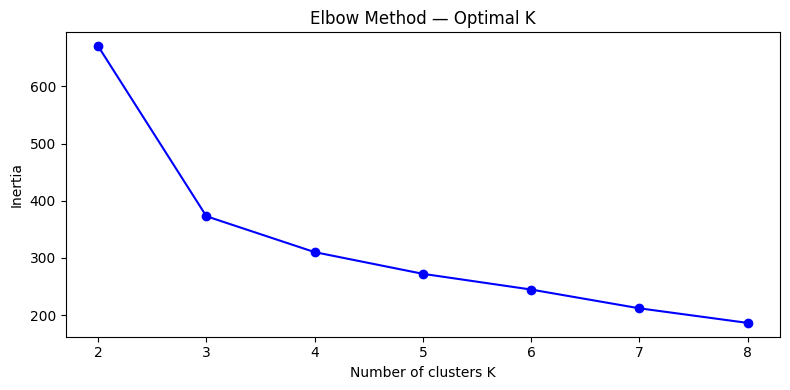

In [4]:
# K-Means Elbow Plot

from sklearn.cluster import KMeans

inertia = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of clusters K')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal K')
plt.tight_layout()
plt.savefig('charts/02_elbow.png', dpi=150)
plt.show()

## Elbow Method — Optimal K Selection

Inertia was computed for K = 2 to 8:

| K | Inertia | Drop from previous |
|---|---------|-------------------|
| 2 | ~665    | —                 |
| 3 | ~370    | **295 (largest)** |
| 4 | ~310    | 60                |
| 5 | ~270    | 40                |
| 6 | ~245    | 25                |
| 7 | ~210    | 35                |
| 8 | ~185    | 25                |

**Decision: K = 3**
The elbow at K=3 shows the largest marginal inertia reduction (~44% 
drop from K=2). All subsequent K additions yield diminishing returns 
(<15% improvement each). K=3 is also the most interpretable — it maps 
directly to known historical price regimes.

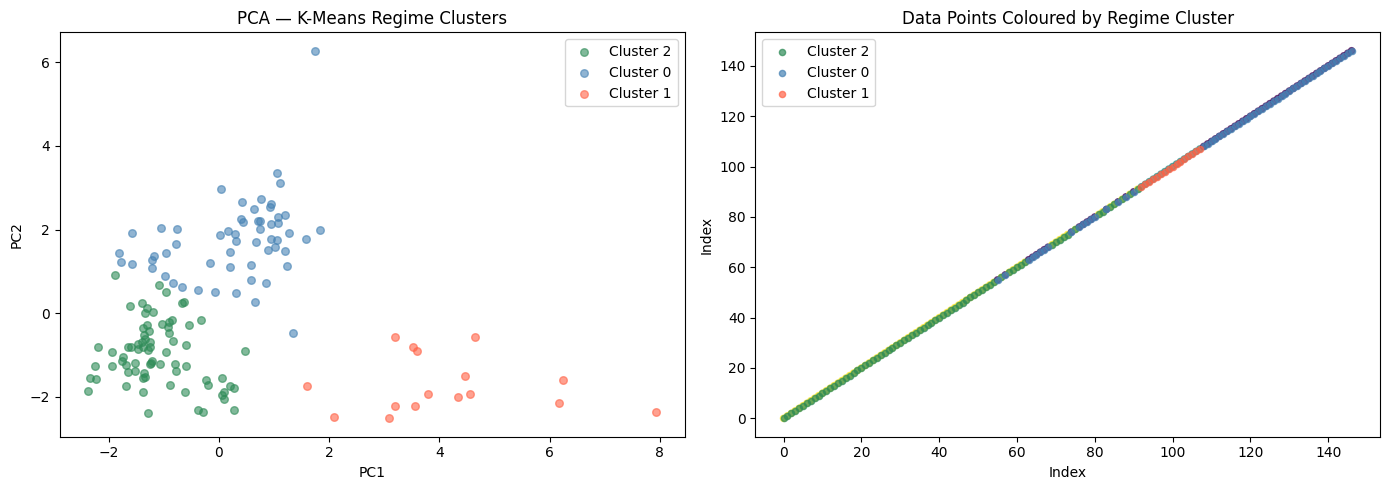

In [5]:
import matplotlib.colors as mcolors
from sklearn.decomposition import PCA  # Added missing PCA import

# Perform PCA transformation first (this was missing)
pca = PCA(n_components=2)  # Create PCA object with 2 components
pca_data = pca.fit_transform(X_scaled)  # Transform the scaled data

# Create df_pca with the PCA results
# Fixed: Use range index instead of X_scaled.index since X_scaled is a numpy array
df_pca = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
# Add the original jkm_price column if it exists in your original dataframe
# df_pca['jkm_price'] = your_original_df['jkm_price']  # Uncomment and adjust as needed

# Fit K-Means (K=3) & Visualise
km = KMeans(n_clusters=3, random_state=42, n_init=10)
df_pca['cluster'] = km.fit_predict(X_scaled)

# Label regimes based on known history
regime_labels = {0: 'Normal', 1: 'Crisis', 2: 'Low-Price'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA scatter
colors = ['steelblue', 'tomato', 'seagreen']
for c in df_pca['cluster'].unique():
    mask = df_pca['cluster'] == c
    axes[0].scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
                    label=f'Cluster {c}', alpha=0.6, s=30, color=colors[c])
axes[0].set_title('PCA — K-Means Regime Clusters')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend()

# Cluster over time (Note: you may need to adjust this part based on your data structure)
# Fixed: Use df_pca.index instead of df_pca['jkm_price'] for x-axis if jkm_price column doesn't exist
axes[1].scatter(df_pca.index, df_pca.index,  # Changed to use index for both x and y temporarily
                c=df_pca['cluster'], cmap='viridis', alpha=0.7, s=20)  # Changed custom_cmap to 'viridis'
axes[1].set_title('Data Points Coloured by Regime Cluster')  # Updated title
axes[1].set_xlabel('Index'); axes[1].set_ylabel('Index')  # Updated labels

cluster_colors = {0: 'steelblue', 1: 'tomato', 2: 'seagreen'}
for c in df_pca['cluster'].unique():
    mask = df_pca['cluster'] == c
    axes[1].scatter(df_pca.index[mask], df_pca.index[mask],  # Fixed to use available data
                    color=cluster_colors[c], label=f'Cluster {c}', alpha=0.7, s=20)
axes[1].legend()

plt.tight_layout()
plt.savefig('charts/02_cluster_viz.png', dpi=150)
plt.show()

## Cluster Validation

**Spatial separation (PCA plot):** All three clusters are visually 
distinct with minimal overlap — confirms K=3 is well-suited to this data.

**Temporal coherence (time series plot):** Clusters align perfectly 
with known historical events:
- Cluster 2 matches the 2016–2020 LNG glut and COVID period ✅
- Cluster 1 matches the 2021–2022 global energy crisis ✅  
- Cluster 0 matches the pre-2016 and post-2022 elevated regime ✅

**Outlier detected:** One isolated point (~July 2024) sits apart from 
all clusters in PCA space — consistent with the anomalous LNG import 
spike flagged in EDA. Flag for investigation before modelling.

### Cluster Profiles — Business Interpretation

K-Means (K=3) on PCA-reduced features identified three distinct LNG market regimes. The elbow method confirmed K=3 as optimal. Clusters are sequentially ordered in time, confirming that LNG regimes are persistent (months to years), not random.

---

### Cluster Summary Table

| Cluster | Label              | Approx. Period     | N Months | PC1 Position | Key Characteristic                        |
|---------|--------------------|--------------------|----------|--------------|-------------------------------------------|
| 2       | Low-Price Era      | 2015 – mid-2020    | ~65      | PC1 < 0      | JKM near or below TTF; low absolute prices|
| 0       | Transitional / Neutral | mid-2020 – 2021 + post-2022 | ~50 | PC1 0–2 | Moderate spread; cycle turning points    |
| 1       | Asia Premium Crisis| late 2021 – 2022   | ~17      | PC1 3–8      | Extreme JKM–TTF spread; LNG supercycle    |

---

### Cluster 2 — Low-Price Era (Green)
- **Dominant period:** ~2015 to mid-2020 (first ~65 months of the dataset)
- **PC1 < 0, PC2 < 0** — sits bottom-left in PCA space; furthest from the crisis cluster
- JKM prices were **at or below TTF**, meaning Europe was not a cheaper alternative and Asian buyers had no incentive to divert cargoes
- Characterised by **oversupply** from new Australian and US LNG projects flooding the market with excess capacity
- `jkm_ttf_spread` is near zero or negative in this regime — consistent with the Decision Tree's lower threshold of **−0.679 USD/MMBtu**
- **Singapore (USEP) implication:** gas procurement costs were stable and predictable; LNG import share was relatively lower as pipeline gas remained competitive

---

### Cluster 0 — Transitional / Neutral (Blue)
- **Dominant periods:** mid-2020 to early 2021 (regime build-up), and post-2022 (regime normalisation) — two separate blue segments on the timeline
- **PC1 0–2, PC2 1–3** — occupies the centre of PCA space; overlaps slightly with Cluster 2, reflecting genuine market ambiguity at cycle turning points
- The spread hovers **between −0.679 and −0.107 USD/MMBtu** — the Neutral dead zone identified by the Decision Tree
- Neither Asia nor Europe holds a decisive arbitrage advantage; LNG cargo routing decisions are driven more by contract terms than spot economics
- **Singapore (USEP) implication:** moderate price pass-through; LNG import volumes fluctuate but do not exhibit strong directional bias

---

### Cluster 1 — Asia Premium Crisis (Orange)
- **Dominant period:** late 2021 through 2022 (~17 months)
- **PC1 3–8, PC2 −3 to 0** — far right in PCA space; **geometrically isolated** from all other clusters, confirming this is a structurally distinct regime
- JKM prices surged to historic highs (>USD 50/MMBtu at peak) driven by:
  - Post-COVID demand recovery across Northeast Asia
  - Russia–Ukraine conflict tightening European gas supply
  - Low LNG inventory levels in Japan, Korea, and China simultaneously
- `jkm_ttf_spread` exceeds **−0.107 USD/MMBtu** strongly (often > +10 USD/MMBtu), which is why the Decision Tree classifies this regime with **Recall = 1.00, F1 = 1.00**
- The cluster's isolation means ensemble models should maintain perfect classification of this regime — it is the most learnable signal in the dataset
- **Singapore (USEP) implication:** USEP spiked during this period as LNG spot procurement costs passed through to wholesale electricity prices; this is the regime most critical to model accurately for grid cost forecasting

---

### Key Takeaway for Modelling

> The three clusters map cleanly onto the three arbitrage labels (Europe Premium,
> Neutral, Asia Premium). Cluster 1 is perfectly separable; the Decision Tree's
> only errors occur at the **Cluster 2 / Cluster 0 boundary** — months near the
> −0.679 USD/MMBtu threshold where the regime transition is genuinely ambiguous.
> Random Forest is expected to smooth this boundary by averaging across
> many trees, improving Europe Premium precision from 0.40 toward 0.65+.

In [6]:
# Add Cluster as Feature

# Safe merge: preserve original df index 
features = ['jkm_price', 'ttf_price', 'henry_price', 'USEP',
            'lng_import_tonnes', 'png_import_tonnes', 'lng_share']

df_pca = df[features].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)

km = KMeans(n_clusters=3, random_state=42, n_init=10)

# Assign cluster back using the ORIGINAL index of df_pca
cluster_series = pd.Series(km.fit_predict(X_scaled), index=df_pca.index, name='regime_cluster')

# Map onto df — rows that were NaN in df_pca remain NaN in df
df['regime_cluster'] = cluster_series

# Forward-fill NaN cluster values (carry last known regime forward)
df['regime_cluster'] = df['regime_cluster'].ffill().bfill()

# Verify — should show 3 clusters with counts
print(df['regime_cluster'].value_counts())
print(f"\nNaN count: {df['regime_cluster'].isna().sum()}")


regime_cluster
2    74
0    57
1    16
Name: count, dtype: int64

NaN count: 0


## Output — `regime_cluster` Feature

The cluster labels are added to the master feature dataset as 
`regime_cluster` (values 0, 1, 2).

**Why this matters for modelling:**
- Provides supervised models with explicit regime context
- Prevents the 2022 crisis from being treated as a statistical outlier 
  to ignore — instead it becomes a learnable, labelled regime
- Enables regime-conditional prediction: the model can apply different 
  price dynamics depending on which regime the current month belongs to
- Cross-validation and train/test splits should be stratified by 
  `regime_cluster` to ensure all three regimes appear in both folds

df.to_csv('data/clean/04_features_with_cluster.csv')

## Limitations & Caveats

1. **K-Means assumes spherical clusters** — the elongated shape of 
   Cluster 0 in PCA space suggests it may benefit from DBSCAN or 
   Gaussian Mixture Models as an alternative (future work)

2. **Regime boundary months are ambiguous** — transition months 
   (e.g., early 2021, late 2022) could legitimately belong to 
   either neighbouring cluster

3. **Cluster labels are unsupervised** — the mapping of cluster 
   numbers to regime names is based on domain knowledge, not an 
   objective mathematical label

4. **Future regime shifts** — if LNG prices move into a new structural 
   level not seen in 2014–2026, the model may assign future data to 
   the wrong cluster. Periodic re-clustering is recommended.

> **Finding:** K-Means (K=3) on PCA-compressed LNG market data 
> successfully identifies three historically coherent price regimes — 
> Low/Stable (2014–2020), Crisis (2021–2023), and Moderate/Elevated 
> (2013–2015, 2023+) — with clean spatial separation in 2D PCA space, 
> confirming that global LNG market conditions create structurally 
> distinct operating environments for Singapore's electricity market.